# Waste Type Identification — Esperimento 4: selezione della *ricetta* su una *val-dura* interna

**Scopo.** Gli esperimenti precedenti hanno mostrato che sulla validazione "pulita" le ricette miti
(`light`, `geo_rrc`, `weighted_loss`, baseline) sono **statisticamente pari** (tutte entro il rumore
±0.005 della cross-validation). La val pulita è disegnata dalla stessa distribuzione del training,
quindi **non vede** il pezzo di difficoltà in più che avrà il test privato. Per decidere la ricetta su un criterio fondato, costruiamo una **val-dura
interna**: le stesse immagini di validazione, perturbate in modo **moderato e realistico**.

> Non stiamo estendendo il training set: stiamo solo *stressando la valutazione*.
Nessun riaddestramento — riusiamo i pesi già salvati in `models/` e li valutiamo così come sono.

**Perturbazioni.** Riquadratura/zoom e piccola
rotazione, degrado di risoluzione,
ricompressione JPEG e fotometria mite, rumore sensore lieve.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Percorsi
BASE              = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'
DATASET_DIR       = Path('/content/dataset_local')                              # copia locale
SPLIT_CSV         = BASE / 'splits' / 'split.csv'
MODELS_DIR        = BASE / 'models'
RESULTS_DIR       = BASE / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Configurazione
IMG_SIZE   = 224
NUM_CLASSES = 8
SEED       = 1234
HARD_LEVEL = 'mild'                                                             # 'mild' oppure 'moderate'
EVAL_BATCH = 128

CLASS_NAMES = ['battery','clothing','glass','metal','organic','papery','plastic','undifferentiated']

CANDIDATES = {
    'baseline (CE)'      : 'resnet18_baseline.pth',
    'light'              : 'resnet18_aug_light.pth',
    'geo_rrc (light+RRC)': 'resnet18_geo_rrc.pth',
    'weighted_loss'      : 'resnet18_imbalance_weighted_loss.pth',
    'strong'             : 'resnet18_aug_strong.pth',
    'sampler'            : 'resnet18_imbalance_sampler.pth',
    'geo_rrc+cutmix'     : 'resnet18_geo_rrc_cutmix.pth',
}
REAL_CANDIDATES = {'light', 'geo_rrc (light+RRC)', 'weighted_loss'}

print('HARD_LEVEL =', HARD_LEVEL)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HARD_LEVEL = mild


## 1. Copia locale del dataset

In [ ]:
import shutil, time
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time(); shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time()-t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copia locale gia presente: /content/dataset_local


## 2. Carico lo split di validazione e risolvo i percorsi

In [ ]:
import pandas as pd

df = pd.read_csv(SPLIT_CSV)
val = df[df['split'] == 'val'].reset_index(drop=True)
print(f'Val: {len(val)} immagini')
assert val['label'].between(0, NUM_CLASSES-1).all(), 'Etichette fuori range 0..7'

def resolve(fp):
    fp = str(fp)
    for cand in (DATASET_DIR / fp, DRIVE_DATASET_DIR / fp, BASE / fp, Path(fp),
                 DATASET_DIR / Path(fp).name):
        if cand.exists():
            return cand
    return None

val['resolved'] = val['filepath'].map(resolve)
missing = val['resolved'].isna().sum()
assert missing == 0, (f'{missing} immagini non risolte. Controlla la colonna filepath del CSV. '
                      f'Esempio non risolto: {val.loc[val["resolved"].isna(), "filepath"].iloc[0]}')
print('Esempio percorso risolto:', val['resolved'].iloc[0])

samples = list(zip(val['resolved'].tolist(), val['label'].astype(int).tolist()))

Val: 3102 immagini
Esempio percorso risolto: /content/dataset_local/battery/battery447.jpg


## 3. Perturbazione "dura" (moderata e deterministica)

In [ ]:
import io, random
import numpy as np
from PIL import Image, ImageEnhance

LEVELS = {
    'mild':     dict(scale=(0.80,1.00), rot=6,  res=(0.60,0.80), jpeg=(60,80), photo=0.12, hue=0.03, noise=0.0),
    'moderate': dict(scale=(0.60,1.00), rot=12, res=(0.35,0.60), jpeg=(35,60), photo=0.25, hue=0.06, noise=6.0),
}

def _rng_for(index, seed=SEED):
    return random.Random(seed * 1_000_003 + int(index))

def hard_perturb(img, index, level=HARD_LEVEL, seed=SEED):
    p = LEVELS[level]; r = _rng_for(index, seed)
    W, H = img.size
    s = r.uniform(*p['scale'])
    cw, ch = max(1, int(W*s)), max(1, int(H*s))
    x0 = r.randint(0, W-cw); y0 = r.randint(0, H-ch)
    img = img.crop((x0, y0, x0+cw, y0+ch))
    img = img.rotate(r.uniform(-p['rot'], p['rot']), resample=Image.BILINEAR,
                     expand=False, fillcolor=(128,128,128))
    d = p['photo']
    for Enh in (ImageEnhance.Brightness, ImageEnhance.Contrast, ImageEnhance.Color):
        img = Enh(img).enhance(1.0 + r.uniform(-d, d))
    if p['hue'] > 0:
        hsv = np.asarray(img.convert('HSV')).astype(np.int16)
        hsv[..., 0] = (hsv[..., 0] + int(r.uniform(-p['hue'], p['hue'])*255)) % 256
        img = Image.fromarray(hsv.astype(np.uint8), 'HSV').convert('RGB')
    f = r.uniform(*p['res'])
    w2, h2 = max(1, int(img.size[0]*f)), max(1, int(img.size[1]*f))
    img = img.resize((w2, h2), Image.BILINEAR).resize((W, H), Image.BILINEAR)
    if p['noise'] > 0:
        arr = np.asarray(img).astype(np.float32)
        rs = np.random.RandomState(seed*7 + int(index))
        arr = np.clip(arr + rs.normal(0, p['noise'], arr.shape), 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)
    q = r.randint(*p['jpeg'])
    buf = io.BytesIO(); img.save(buf, format='JPEG', quality=q); buf.seek(0)
    return Image.open(buf).convert('RGB')

## 4. Preprocessing del modello e costruzione delle cache

In [ ]:
import torch
from torchvision import transforms
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

_preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def _load_rgb(path):
    return Image.open(path).convert('RGB')

N = len(samples)
y = torch.tensor([lab for _, lab in samples], dtype=torch.long)
clean_X = torch.empty((N, 3, IMG_SIZE, IMG_SIZE), dtype=torch.float16)
hard_X  = torch.empty((N, 3, IMG_SIZE, IMG_SIZE), dtype=torch.float16)

for i, (path, _) in enumerate(tqdm(samples, desc='Preprocesso clean+hard')):
    img = _load_rgb(path)
    clean_X[i] = _preprocess(img).half()
    hard_X[i]  = _preprocess(hard_perturb(img, i)).half()

print('Cache pronte:', tuple(clean_X.shape), '| RAM ~', round(2*clean_X.element_size()*clean_X.nelement()/1e9,2), 'GB')

Device: cuda


Preprocesso clean+hard:   0%|          | 0/3102 [00:00<?, ?it/s]

/tmp/ipykernel_713/1317893171.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(hsv.astype(np.uint8), 'HSV').convert('RGB')


Cache pronte: (3102, 3, 224, 224) | RAM ~ 1.87 GB


## 5. Valutazione di ogni ricetta su clean-val e hard-val

In [ ]:
import torch.nn as nn
from torchvision import models
from sklearn.metrics import balanced_accuracy_score, recall_score

def build_resnet18():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def load_ckpt(fname):
    state = torch.load(MODELS_DIR / fname, map_location='cpu')
    if isinstance(state, dict) and 'state_dict' in state:
        state = state['state_dict']
    m = build_resnet18(); m.load_state_dict(state)
    return m.to(device).eval()

@torch.no_grad()
def predict_all(model, X):
    preds = torch.empty(X.shape[0], dtype=torch.long)
    for s in range(0, X.shape[0], EVAL_BATCH):
        batch = X[s:s+EVAL_BATCH].float().to(device)
        preds[s:s+EVAL_BATCH] = model(batch).argmax(1).cpu()
    return preds.numpy()

def metrics(y_true, y_pred):
    ba  = balanced_accuracy_score(y_true, y_pred)
    tpr = recall_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
    return ba, tpr

y_np = y.numpy()
rows, tpr_rows = [], []
for name, fname in CANDIDATES.items():
    if not (MODELS_DIR / fname).exists():
        print(f'[skip] {name}: {fname} non trovato'); continue
    model = load_ckpt(fname)
    ba_c, tpr_c = metrics(y_np, predict_all(model, clean_X))
    ba_h, tpr_h = metrics(y_np, predict_all(model, hard_X))
    del model; torch.cuda.empty_cache()
    rows.append(dict(recipe=name, candidate=name in REAL_CANDIDATES,
                     clean_balacc=round(ba_c,4), hard_balacc=round(ba_h,4),
                     drop=round(ba_c-ba_h,4)))
    for k, cls in enumerate(CLASS_NAMES):
        tpr_rows.append(dict(recipe=name, **{'class':cls,
                        'tpr_clean':round(float(tpr_c[k]),4), 'tpr_hard':round(float(tpr_h[k]),4)}))
    print(f'{name:22s}  clean {ba_c:.4f}  |  hard {ba_h:.4f}  (drop {ba_c-ba_h:+.4f})')

baseline (CE)           clean 0.9666  |  hard 0.9374  (drop +0.0292)
light                   clean 0.9679  |  hard 0.9322  (drop +0.0356)
geo_rrc (light+RRC)     clean 0.9643  |  hard 0.9464  (drop +0.0179)
weighted_loss           clean 0.9606  |  hard 0.9356  (drop +0.0251)
strong                  clean 0.9540  |  hard 0.9389  (drop +0.0152)
sampler                 clean 0.9619  |  hard 0.9256  (drop +0.0364)
geo_rrc+cutmix          clean 0.9649  |  hard 0.9384  (drop +0.0265)


## 6. Tabella, salvataggio e raccomandazione
Decisione: tra i **candidati reali** si sceglie la **hard-val
Balanced Accuracy** piu' alta.

In [ ]:
res = pd.DataFrame(rows).sort_values('hard_balacc', ascending=False).reset_index(drop=True)
tpr_df = pd.DataFrame(tpr_rows)
res.to_csv(RESULTS_DIR / f'hardval_recipe_comparison_{HARD_LEVEL}.csv', index=False)
tpr_df.to_csv(RESULTS_DIR / f'hardval_per_class_tpr_{HARD_LEVEL}.csv', index=False)
print(res.to_string(index=False)); print()

cand = res[res['candidate']].reset_index(drop=True)
if len(cand):
    best = cand.iloc[0]
    within = cand[cand['hard_balacc'] >= best['hard_balacc'] - 0.005]['recipe'].tolist()
    pick = 'light' if 'light' in within else best['recipe']
    print(f"Miglior candidato su hard-val: {best['recipe']} ({best['hard_balacc']:.4f})")
    print(f"Entro il rumore (~0.005): {within}")
    print(f">>> RICETTA CONSIGLIATA: {pick}")

             recipe  candidate  clean_balacc  hard_balacc   drop
geo_rrc (light+RRC)       True        0.9643       0.9464 0.0179
             strong      False        0.9540       0.9389 0.0152
     geo_rrc+cutmix      False        0.9649       0.9384 0.0265
      baseline (CE)      False        0.9666       0.9374 0.0292
      weighted_loss       True        0.9606       0.9356 0.0251
              light       True        0.9679       0.9322 0.0356
            sampler      False        0.9619       0.9256 0.0364

Miglior candidato su hard-val: geo_rrc (light+RRC) (0.9464)
Entro il rumore (~0.005): ['geo_rrc (light+RRC)']
>>> RICETTA CONSIGLIATA: geo_rrc (light+RRC)


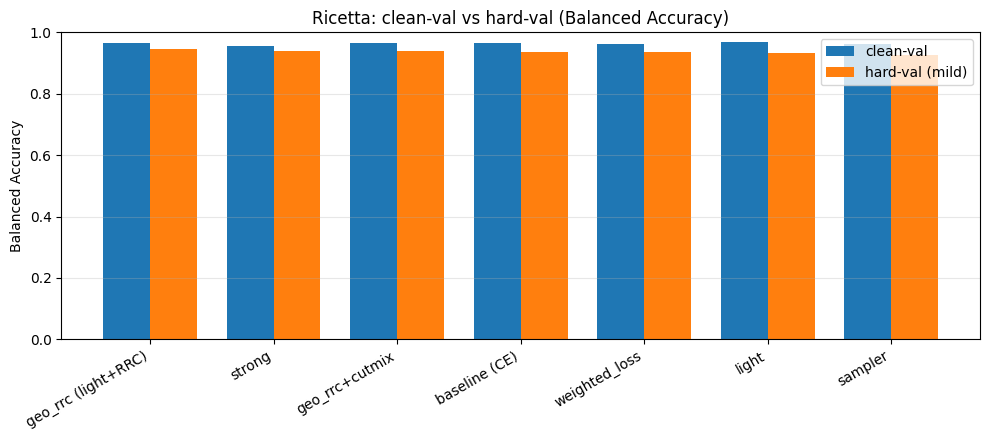

Salvati in results/: tabella CSV, TPR per classe CSV, grafico PNG


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

order = res['recipe'].tolist()
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, res['clean_balacc'], w, label='clean-val')
ax.bar(x + w/2, res['hard_balacc'],  w, label=f'hard-val ({HARD_LEVEL})')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_ylabel('Balanced Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Ricetta: clean-val vs hard-val (Balanced Accuracy)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'hardval_recipe_balacc_{HARD_LEVEL}.png', dpi=130)
plt.show()
print('Salvati in results/: tabella CSV, TPR per classe CSV, grafico PNG')